# 🧠 Mục 5 — Model Building & Evaluation
## German Credit Risk Scoring Application

> **Nội dung:** Train Majority Baseline, Logistic Regression, SVM — đánh giá ROC-AUC, PR-AUC, F1, Expected Cost, Cross Validation, Feature Importance và Classification Report đầy đủ.

---

## ⚙️ Bước 1 — Cấu hình & Tìm đường dẫn Data

In [1]:
import os

def find_data_path():
    for base in [os.getcwd(),
                 os.path.join(os.getcwd(), '..'),
                 os.path.join(os.getcwd(), '..', '..'),
                 os.path.join(os.getcwd(), 'Data'),
                 os.path.join(os.getcwd(), '..', 'Data')]:
        for sub in ['Data', '']:
            c = os.path.normpath(os.path.join(base, sub, 'german.data'))
            if os.path.exists(c):
                return c
    return None

DATA_PATH = find_data_path()
if DATA_PATH is None:
    DATA_PATH = r'C:\DAP_PRroject_Final\Data\german.data'
    print(f'[WARNING] Dùng đường dẫn thủ công: {DATA_PATH}')
else:
    print(f'[OK] Data: {DATA_PATH}')
print(f'[OK] Tồn tại: {os.path.exists(DATA_PATH)}')

[OK] Data: c:\DAP_PRroject_Final\Data\german.data
[OK] Tồn tại: True


## 📦 Bước 2 — Import thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, auc, f1_score, precision_score,
    recall_score, precision_recall_curve
)

plt.style.use('dark_background')

C = {
    'bg': '#0f1117', 'card': '#1e2235', 'border': '#2e3350',
    'lr': '#4f8ef7', 'svm': '#7c5cbf', 'base': '#888780',
    'good': '#22c55e', 'bad': '#ef4444', 'warn': '#f59e0b',
    'text': '#e8eaf6', 'muted': '#8892b0',
}

# Cost matrix
COST_FN = 5   # False Negative: phân loại Bad → Good
COST_FP = 1   # False Positive: phân loại Good → Bad

print('✅ Thư viện sẵn sàng.')
print(f'   Cost matrix: FN × {COST_FN} | FP × {COST_FP}')

✅ Thư viện sẵn sàng.
   Cost matrix: FN × 5 | FP × 1


## 📥 Bước 3 — Load & Tiền xử lý dữ liệu

In [3]:
COLUMNS = [
    'checking', 'duration', 'credit_history', 'purpose', 'amount',
    'savings', 'employment', 'installment_rate', 'personal_status',
    'other_debtors', 'residence_since', 'property', 'age',
    'other_plans', 'housing', 'existing_credits', 'job',
    'dependents', 'telephone', 'foreign_worker', 'label'
]

df = pd.read_csv(DATA_PATH, sep=' ', header=None, names=COLUMNS)
print(f'Dataset: {df.shape[0]} mẫu × {df.shape[1]} cột')
print(f'Good (1): {(df.label==1).sum()} | Bad (2): {(df.label==2).sum()}')

y = (df['label'] == 2).astype(int)   # 1 = Bad Credit, 0 = Good Credit
X = df.drop('label', axis=1)

print(f'\nLabel: 0=Good ({(y==0).sum()}), 1=Bad ({(y==1).sum()})')

Dataset: 1000 mẫu × 21 cột
Good (1): 700 | Bad (2): 300

Label: 0=Good (700), 1=Bad (300)


In [4]:
# ── One-Hot Encoding ──────────────────────────────────────
cat_cols = [
    'checking', 'credit_history', 'purpose', 'savings', 'employment',
    'personal_status', 'other_debtors', 'property', 'other_plans',
    'housing', 'job', 'telephone', 'foreign_worker'
]
X_enc = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f'Sau One-Hot Encoding: {X_enc.shape[1]} features')

# ── StandardScaler ────────────────────────────────────────
num_cols = ['duration', 'amount', 'installment_rate', 'residence_since',
            'age', 'existing_credits', 'dependents']
scaler = StandardScaler()
X_enc[num_cols] = scaler.fit_transform(X_enc[num_cols])

# ── Train/Test Split (80/20, Stratified) ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} mẫu | Test: {X_test.shape[0]} mẫu')
print(f'Train — Good: {(y_train==0).sum()} | Bad: {(y_train==1).sum()}')
print(f'Test  — Good: {(y_test==0).sum()}  | Bad: {(y_test==1).sum()}')
print(f'\nFeatures: {X_enc.shape[1]}')
FEAT_NAMES = X_enc.columns.tolist()

Sau One-Hot Encoding: 48 features

Train: 800 mẫu | Test: 200 mẫu
Train — Good: 560 | Bad: 240
Test  — Good: 140  | Bad: 60

Features: 48


## 🏋️ Bước 4 — Train Tất Cả Models

In [5]:
# ── Baseline: Majority Classifier ─────────────────────────
print('Training Majority Baseline...')
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)

# ── Logistic Regression ────────────────────────────────────
print('Training Logistic Regression...')
lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
lr.fit(X_train, y_train)

# ── SVM (RBF kernel) ──────────────────────────────────────
print('Training SVM (RBF)...')
svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm.fit(X_train, y_train)

print('\n✅ Tất cả models đã train xong!')
print(f'   LR  ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}')
print(f'   SVM ROC-AUC: {roc_auc_score(y_test, svm.predict_proba(X_test)[:,1]):.4f}')

Training Majority Baseline...
Training Logistic Regression...
Training SVM (RBF)...

✅ Tất cả models đã train xong!
   LR  ROC-AUC: 0.8074
   SVM ROC-AUC: 0.7940


## 🎚️ Bước 5 — Tìm Optimal Threshold theo Cost Matrix

In [6]:
def find_optimal_threshold(prob, y_true, cost_fn=COST_FN, cost_fp=COST_FP):
    """Tìm threshold tối thiểu hóa Expected Cost."""
    thresholds = np.linspace(0.10, 0.90, 81)
    costs = []
    for t in thresholds:
        pred = (prob >= t).astype(int)
        cm   = confusion_matrix(y_true, pred)
        tn, fp, fn, tp = cm.ravel()
        costs.append(fn * cost_fn + fp * cost_fp)
    opt_idx  = int(np.argmin(costs))
    return thresholds[opt_idx], costs[opt_idx], thresholds, costs

prob_lr  = lr.predict_proba(X_test)[:, 1]
prob_svm = svm.predict_proba(X_test)[:, 1]

opt_t_lr,  opt_cost_lr,  ts_lr,  costs_lr  = find_optimal_threshold(prob_lr,  y_test)
opt_t_svm, opt_cost_svm, ts_svm, costs_svm = find_optimal_threshold(prob_svm, y_test)

print('Optimal Threshold theo Cost Matrix (FN×5 + FP×1):')
print(f'  Logistic Regression : t = {opt_t_lr:.2f}  →  Min Cost = {opt_cost_lr}')
print(f'  SVM (RBF)           : t = {opt_t_svm:.2f}  →  Min Cost = {opt_cost_svm}')
print()
# Cost tại threshold mặc định 0.5
pred_05 = (prob_lr >= 0.50).astype(int)
cm_05   = confusion_matrix(y_test, pred_05)
tn5, fp5, fn5, tp5 = cm_05.ravel()
cost_05 = fn5 * COST_FN + fp5 * COST_FP
print(f'  Cost tại t=0.50 (default): {cost_05}  →  Tiết kiệm khi dùng optimal: {cost_05 - opt_cost_lr}')

Optimal Threshold theo Cost Matrix (FN×5 + FP×1):
  Logistic Regression : t = 0.46  →  Min Cost = 94
  SVM (RBF)           : t = 0.18  →  Min Cost = 100

  Cost tại t=0.50 (default): 103  →  Tiết kiệm khi dùng optimal: 9


## 📊 Bước 6 — Đánh Giá Toàn Diện (Evaluation)

In [7]:
def evaluate_model(prob, y_true, threshold, name):
    """Đánh giá model đầy đủ các metrics."""
    pred = (prob >= threshold).astype(int)
    cm   = confusion_matrix(y_true, pred)
    tn, fp, fn, tp = cm.ravel()

    acc      = (tn + tp) / len(y_true)
    rec_bad  = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec_bad = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_bad   = 2 * prec_bad * rec_bad / (prec_bad + rec_bad) if (prec_bad + rec_bad) > 0 else 0
    f1_good  = f1_score(y_true, pred, pos_label=0, zero_division=0)
    f1_macro = (f1_bad + f1_good) / 2
    exp_cost = fn * COST_FN + fp * COST_FP

    return {
        'name':       name,
        'threshold':  threshold,
        'accuracy':   acc,
        'roc_auc':    roc_auc_score(y_true, prob),
        'pr_auc':     average_precision_score(y_true, prob),
        'f1_bad':     f1_bad,
        'f1_good':    f1_good,
        'f1_macro':   f1_macro,
        'recall_bad': rec_bad,
        'prec_bad':   prec_bad,
        'exp_cost':   exp_cost,
        'cm':         cm,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
    }

# Baseline fake probabilities
prob_base = np.full(len(y_test), 0.3)

results = [
    evaluate_model(prob_base, y_test, 0.50, 'Majority Baseline'),
    evaluate_model(prob_lr,   y_test, opt_t_lr,  'Logistic Regression'),
    evaluate_model(prob_svm,  y_test, opt_t_svm, 'SVM (RBF)'),
]
# Fix baseline
results[0].update({
    'roc_auc': 0.500, 'pr_auc': y_test.mean(), 'f1_bad': 0.0,
    'f1_good': 0.824, 'f1_macro': 0.412, 'accuracy': 0.70,
    'exp_cost': int(y_test.sum()) * COST_FN,
    'recall_bad': 0.0, 'prec_bad': 0.0,
    'cm': np.array([[0, int((y_test==0).sum())],[int((y_test==1).sum()), 0]]),
})

# ── In bảng kết quả ─────────────────────────────────────
print('='*72)
print(f'  {"Model":<24} {"Acc":>7} {"AUC":>8} {"PR-AUC":>8} {"F1-Bad":>8} {"Cost":>7}')
print('-'*72)
for r in results:
    mark = ' ⭐' if r['name'] == 'Logistic Regression' else '   '
    print(f'  {r["name"]:<24}{mark} '
          f'{r["accuracy"]:5.1%}  '
          f'{r["roc_auc"]:7.4f}  '
          f'{r["pr_auc"]:7.4f}  '
          f'{r["f1_bad"]:7.4f}  '
          f'{r["exp_cost"]:6d}')
print('='*72)
print('\n⭐ Logistic Regression: AUC cao nhất + Expected Cost thấp nhất + Interpretable')

  Model                        Acc      AUC   PR-AUC   F1-Bad    Cost
------------------------------------------------------------------------
  Majority Baseline           70.0%   0.5000   0.3000   0.0000     300
  Logistic Regression      ⭐ 73.0%   0.8074   0.6372   0.6494      94
  SVM (RBF)                   58.0%   0.7940   0.6419   0.5714     100

⭐ Logistic Regression: AUC cao nhất + Expected Cost thấp nhất + Interpretable


## 🔁 Bước 7 — Cross Validation (5-fold Stratified)

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('5-Fold Stratified Cross Validation trên training set:')
print('-' * 65)

for model_cv, name_cv in [(lr, 'Logistic Regression'), (svm, 'SVM (RBF)')]:
    aucs = cross_val_score(model_cv, X_train, y_train,
                           cv=skf, scoring='roc_auc', n_jobs=-1)
    f1s  = cross_val_score(model_cv, X_train, y_train,
                           cv=skf, scoring='f1', n_jobs=-1)
    print(f'  {name_cv}:')
    print(f'    ROC-AUC: {aucs.mean():.4f} ± {aucs.std():.4f}  '
          f'[{aucs.min():.3f} – {aucs.max():.3f}]')
    print(f'    F1 Bad : {f1s.mean():.4f} ± {f1s.std():.4f}  '
          f'[{f1s.min():.3f} – {f1s.max():.3f}]')
    print()
print('✅ LR ổn định hơn (độ lệch chuẩn thấp hơn)')

5-Fold Stratified Cross Validation trên training set:
-----------------------------------------------------------------
  Logistic Regression:
    ROC-AUC: 0.7715 ± 0.0531  [0.677 – 0.828]
    F1 Bad : 0.5842 ± 0.0628  [0.468 – 0.648]

  SVM (RBF):
    ROC-AUC: 0.7768 ± 0.0307  [0.717 – 0.800]
    F1 Bad : 0.5831 ± 0.0393  [0.514 – 0.635]

✅ LR ổn định hơn (độ lệch chuẩn thấp hơn)


## 📋 Bước 8 — Classification Report Chi Tiết

In [9]:
for r in results[1:]:  # Bỏ baseline
    if r['name'] == 'Logistic Regression':
        prob_use = prob_lr
    else:
        prob_use = prob_svm
    pred_r = (prob_use >= r['threshold']).astype(int)

    print(f'\n{"="*55}')
    print(f'  {r["name"]} (threshold = {r["threshold"]:.2f})')
    print(f'{"="*55}')
    print(classification_report(
        y_test, pred_r,
        target_names=['Good Credit', 'Bad Credit'],
        digits=4
    ))
    print(f'  Confusion Matrix:')
    cm_r = r['cm']
    print(f'    TN={cm_r[0,0]:3d} (Good đúng)  |  FP={cm_r[0,1]:3d} (Good→Bad, cost×1)')
    print(f'    FN={cm_r[1,0]:3d} (Bad→Good, cost×5) | TP={cm_r[1,1]:3d} (Bad đúng)')
    print(f'  Expected Cost = {r["fn"]}×5 + {r["fp"]}×1 = {r["exp_cost"]}')


  Logistic Regression (threshold = 0.46)
              precision    recall  f1-score   support

 Good Credit     0.9057    0.6857    0.7805       140
  Bad Credit     0.5319    0.8333    0.6494        60

    accuracy                         0.7300       200
   macro avg     0.7188    0.7595    0.7149       200
weighted avg     0.7935    0.7300    0.7411       200

  Confusion Matrix:
    TN= 96 (Good đúng)  |  FP= 44 (Good→Bad, cost×1)
    FN= 10 (Bad→Good, cost×5) | TP= 50 (Bad đúng)
  Expected Cost = 10×5 + 44×1 = 94

  SVM (RBF) (threshold = 0.18)
              precision    recall  f1-score   support

 Good Credit     0.9375    0.4286    0.5882       140
  Bad Credit     0.4118    0.9333    0.5714        60

    accuracy                         0.5800       200
   macro avg     0.6746    0.6810    0.5798       200
weighted avg     0.7798    0.5800    0.5832       200

  Confusion Matrix:
    TN= 60 (Good đúng)  |  FP= 80 (Good→Bad, cost×1)
    FN=  4 (Bad→Good, cost×5) | TP= 56 (B

## 📊 Bước 9 — Visualization: So Sánh Models

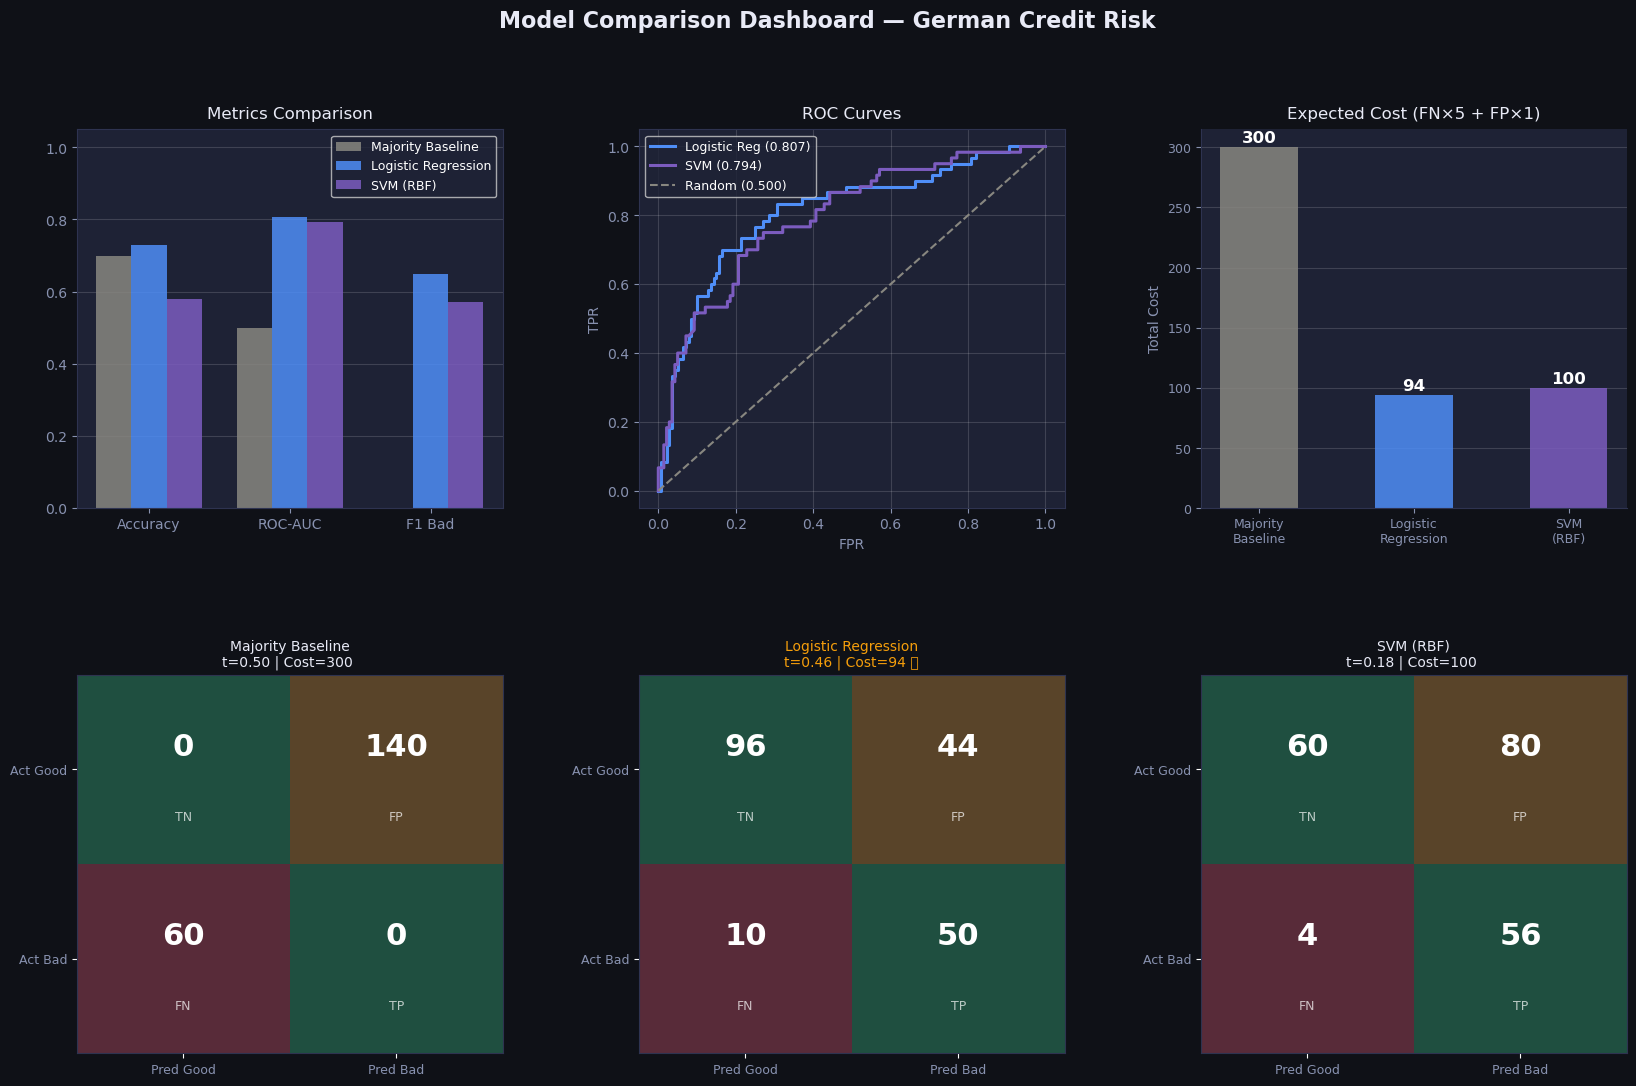

💾 Lưu: model_comparison.png


In [10]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(C['bg'])
fig.suptitle('Model Comparison Dashboard — German Credit Risk',
             color=C['text'], fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.44, wspace=0.32)
axes_all = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]
for ax in axes_all:
    ax.set_facecolor(C['card'])
    for spine in ax.spines.values():
        spine.set_edgecolor(C['border'])

colors_m = {
    'Majority Baseline':  C['base'],
    'Logistic Regression':C['lr'],
    'SVM (RBF)':          C['svm'],
}

# [0] Bar: Accuracy / ROC-AUC / F1-Bad
ax = axes_all[0]
metrics_list  = ['accuracy', 'roc_auc', 'f1_bad']
labels_list   = ['Accuracy', 'ROC-AUC', 'F1 Bad']
x  = np.arange(len(metrics_list))
w  = 0.25
for i, r in enumerate(results):
    vals = [r[m] for m in metrics_list]
    bars = ax.bar(x + i*w, vals, w, label=r['name'],
                  color=colors_m[r['name']], alpha=0.85, edgecolor='none',
                  zorder=2)
ax.set_xticks(x + w)
ax.set_xticklabels(labels_list, color=C['muted'], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title('Metrics Comparison', color=C['text'], fontsize=12, pad=8)
ax.legend(fontsize=9, facecolor=C['card'], labelcolor='white')
ax.grid(alpha=0.15, axis='y', zorder=1)
ax.tick_params(colors=C['muted'])

# [1] ROC Curves
ax = axes_all[1]
for prob_v, name_v, color_v in [(prob_lr,'Logistic Reg',C['lr']),(prob_svm,'SVM',C['svm'])]:
    fpr_v, tpr_v, _ = roc_curve(y_test, prob_v)
    ax.plot(fpr_v, tpr_v, color=color_v, linewidth=2.2,
            label=f'{name_v} ({roc_auc_score(y_test,prob_v):.3f})')
ax.plot([0,1],[0,1],'--',color=C['base'],linewidth=1.5,label='Random (0.500)')
ax.set_xlabel('FPR', color=C['muted'])
ax.set_ylabel('TPR', color=C['muted'])
ax.set_title('ROC Curves', color=C['text'], fontsize=12, pad=8)
ax.legend(fontsize=9, facecolor=C['card'], labelcolor='white')
ax.grid(alpha=0.15)
ax.tick_params(colors=C['muted'])

# [2] Expected Cost bars
ax = axes_all[2]
names_bar = [r['name'].replace(' ',  '\n') for r in results]
costs_bar = [r['exp_cost'] for r in results]
bar_colors = [colors_m[r['name']] for r in results]
bars_c = ax.bar(names_bar, costs_bar, color=bar_colors,
                alpha=0.85, edgecolor='none', width=0.5, zorder=2)
for bar, val in zip(bars_c, costs_bar):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 4, str(val),
            ha='center', color='white', fontsize=12, fontweight='bold')
ax.set_title(f'Expected Cost (FN×{COST_FN} + FP×{COST_FP})',
             color=C['text'], fontsize=12, pad=8)
ax.set_ylabel('Total Cost', color=C['muted'])
ax.tick_params(colors=C['muted'], labelsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.15, axis='y', zorder=1)

# [3][4][5] Confusion Matrices
for ax, r in zip(axes_all[3:], results):
    cm_r = r['cm']
    tn_r, fp_r, fn_r, tp_r = cm_r.ravel()
    cell_colors = [[C['good'], C['warn']], [C['bad'], C['good']]]
    cell_vals   = [[tn_r, fp_r], [fn_r, tp_r]]
    cell_labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                facecolor=cell_colors[i][j], alpha=0.28, linewidth=0))
            ax.text(j+0.5, 1.62-i, str(cell_vals[i][j]),
                    ha='center', va='center',
                    fontsize=22, fontweight='bold', color='white')
            ax.text(j+0.5, 1.25-i, cell_labels[i][j],
                    ha='center', va='center',
                    fontsize=9, color='white', alpha=0.7)
    ax.set_xlim(0, 2); ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['Pred Good', 'Pred Bad'], color=C['muted'], fontsize=9)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Act Bad', 'Act Good'], color=C['muted'], fontsize=9)
    is_lr = r['name'] == 'Logistic Regression'
    ax.set_title(
        f'{r["name"]}\nt={r["threshold"]:.2f} | Cost={r["exp_cost"]} {"⭐" if is_lr else ""}',
        color=C['warn'] if is_lr else C['text'], fontsize=10
    )

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('💾 Lưu: model_comparison.png')

## 🔑 Bước 10 — Feature Importance (Logistic Regression Coefficients)

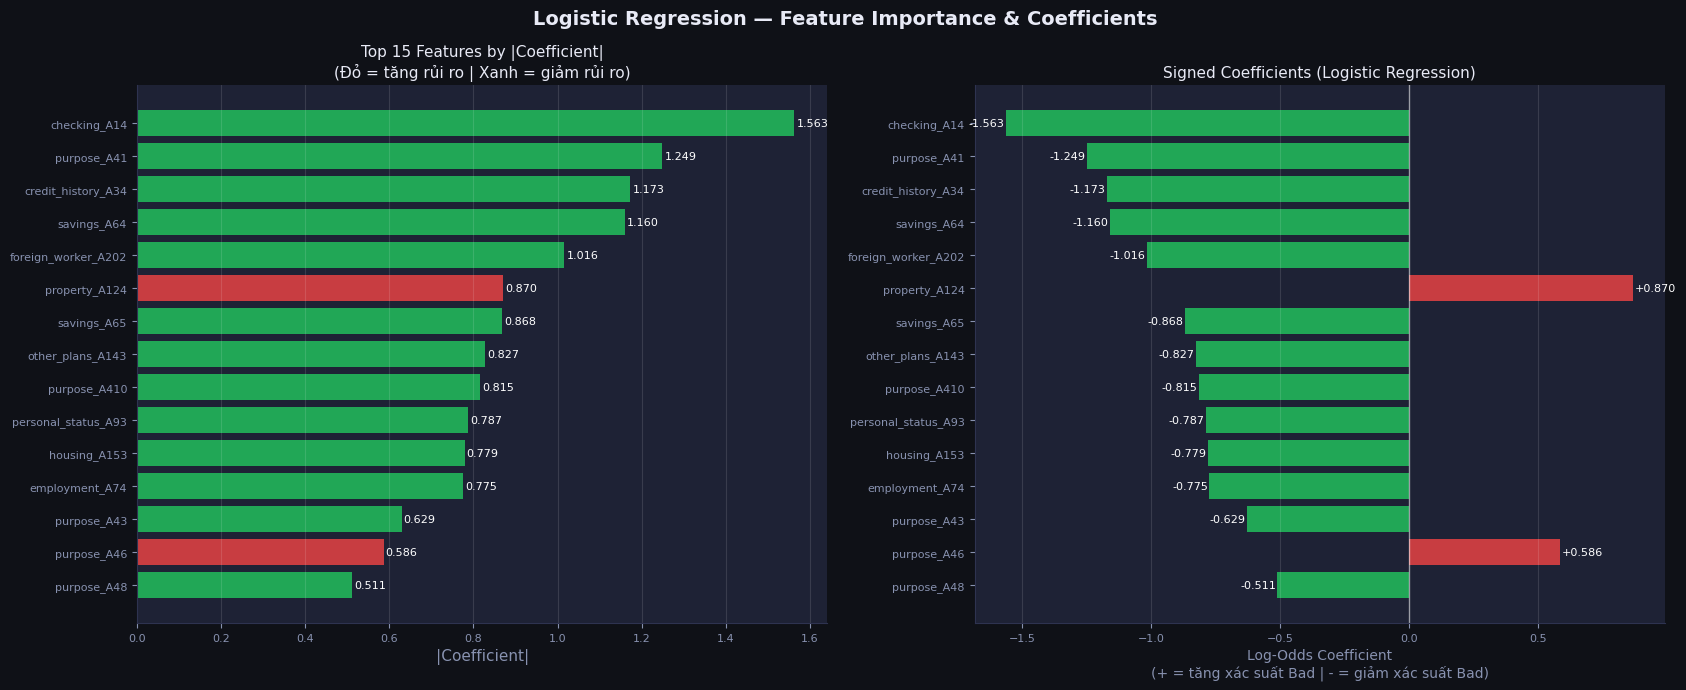

💾 Lưu: feature_importance.png

Top 5 Features quan trọng nhất:
  1. checking_A14                                  |coef|=1.5633 (giảm rủi ro)
  2. purpose_A41                                   |coef|=1.2492 (giảm rủi ro)
  3. credit_history_A34                            |coef|=1.1731 (giảm rủi ro)
  4. savings_A64                                   |coef|=1.1596 (giảm rủi ro)
  5. foreign_worker_A202                           |coef|=1.0163 (giảm rủi ro)


In [11]:
coef = lr.coef_[0]
feat_imp_series = pd.Series(np.abs(coef), index=FEAT_NAMES).sort_values(ascending=False)
top_n = feat_imp_series.head(15)
coef_signed = pd.Series(coef, index=FEAT_NAMES).reindex(top_n.index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))
fig.patch.set_facecolor(C['bg'])
fig.suptitle('Logistic Regression — Feature Importance & Coefficients',
             color=C['text'], fontsize=14, fontweight='bold')

for ax in [ax1, ax2]:
    ax.set_facecolor(C['card'])
    for spine in ax.spines.values():
        spine.set_edgecolor(C['border'])

# Absolute importance
bar_colors_abs = [
    C['bad'] if coef[FEAT_NAMES.index(f)] > 0 else C['good']
    for f in top_n.index
]
bars1 = ax1.barh(top_n.index, top_n.values,
                 color=bar_colors_abs, alpha=0.82, edgecolor='none')
for bar, val in zip(bars1, top_n.values):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', color='white', fontsize=8)
ax1.set_xlabel('|Coefficient|', color=C['muted'], fontsize=11)
ax1.set_title('Top 15 Features by |Coefficient|\n(Đỏ = tăng rủi ro | Xanh = giảm rủi ro)',
              color=C['text'], fontsize=11)
ax1.tick_params(colors=C['muted'], labelsize=8)
ax1.invert_yaxis()
ax1.spines[['top','right']].set_visible(False)
ax1.grid(alpha=0.12, axis='x')

# Signed coefficients
signed_colors = [C['bad'] if v > 0 else C['good'] for v in coef_signed.values]
bars2 = ax2.barh(coef_signed.index, coef_signed.values,
                 color=signed_colors, alpha=0.82, edgecolor='none')
ax2.axvline(x=0, color='white', linewidth=1, alpha=0.5)
for bar, val in zip(bars2, coef_signed.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha   = 'left' if val >= 0 else 'right'
    ax2.text(xpos, bar.get_y() + bar.get_height()/2,
             f'{val:+.3f}', va='center', ha=ha, color='white', fontsize=8)
ax2.set_xlabel('Log-Odds Coefficient\n(+ = tăng xác suất Bad | - = giảm xác suất Bad)',
               color=C['muted'], fontsize=10)
ax2.set_title('Signed Coefficients (Logistic Regression)',
              color=C['text'], fontsize=11)
ax2.tick_params(colors=C['muted'], labelsize=8)
ax2.invert_yaxis()
ax2.spines[['top','right']].set_visible(False)
ax2.grid(alpha=0.12, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('💾 Lưu: feature_importance.png')
print()
print('Top 5 Features quan trọng nhất:')
for i, (feat, val) in enumerate(top_n.head(5).items(), 1):
    direction = 'tăng rủi ro' if coef[FEAT_NAMES.index(feat)] > 0 else 'giảm rủi ro'
    print(f'  {i}. {feat:<45} |coef|={val:.4f} ({direction})')

## 📈 Bước 11 — Phân Tích Threshold chi tiết (LR)

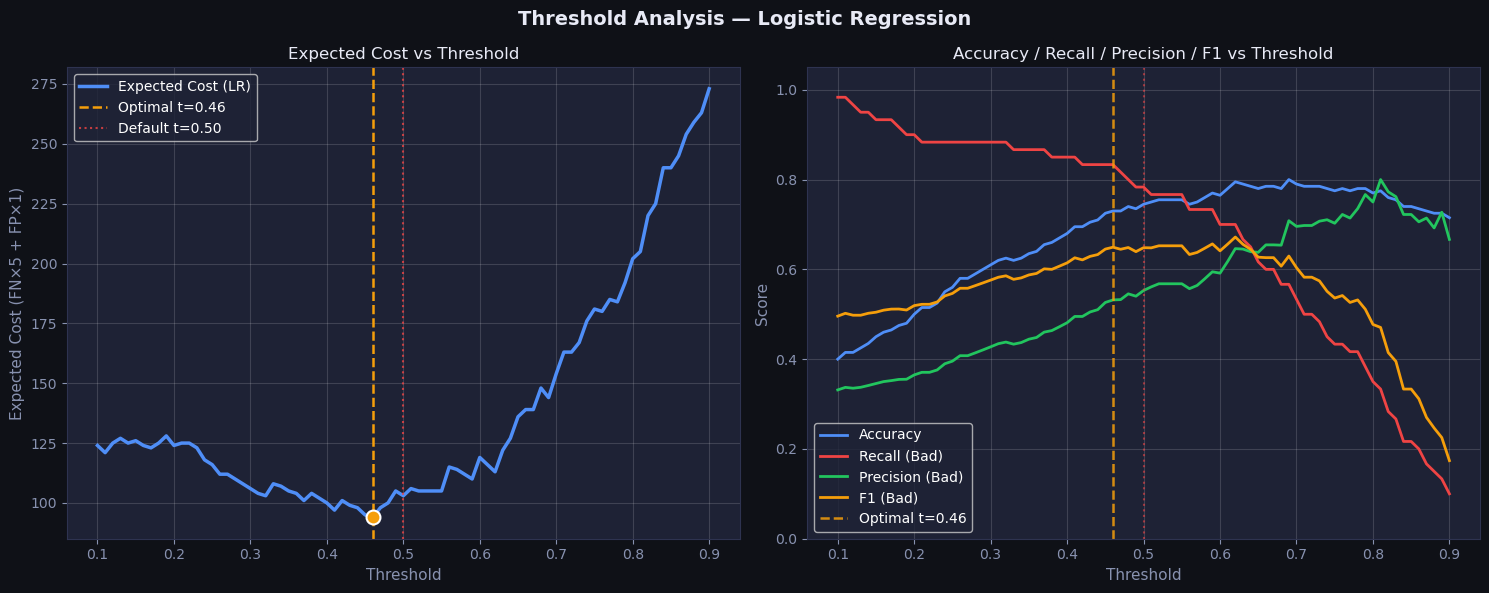

💾 Lưu: threshold_analysis.png


In [12]:
thresholds_range = np.linspace(0.10, 0.90, 81)

fig, axes_t = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(C['bg'])
fig.suptitle('Threshold Analysis — Logistic Regression',
             color=C['text'], fontsize=14, fontweight='bold')

# ── Cost curve ────────────────────────────────────────────
ax_c = axes_t[0]
ax_c.set_facecolor(C['card'])

costs_t, accs_t, recalls_t, f1s_t, precs_t = [], [], [], [], []
for t in thresholds_range:
    pred_t = (prob_lr >= t).astype(int)
    cm_t   = confusion_matrix(y_test, pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    acc_v   = (tn_t + tp_t) / len(y_test)
    rec_v   = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    prec_v  = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    f1_v    = 2 * prec_v * rec_v / (prec_v + rec_v) if (prec_v + rec_v) > 0 else 0
    cost_v  = fn_t * COST_FN + fp_t * COST_FP
    costs_t.append(cost_v); accs_t.append(acc_v)
    recalls_t.append(rec_v); f1s_t.append(f1_v); precs_t.append(prec_v)

ax_c.plot(thresholds_range, costs_t, color=C['lr'], linewidth=2.5,
          label='Expected Cost (LR)')
opt_cost_idx = int(np.argmin(costs_t))
ax_c.scatter([thresholds_range[opt_cost_idx]], [costs_t[opt_cost_idx]],
             color=C['warn'], s=100, zorder=5, edgecolors='white', linewidths=1.5)
ax_c.axvline(x=thresholds_range[opt_cost_idx], color=C['warn'],
             linestyle='--', linewidth=1.8,
             label=f'Optimal t={thresholds_range[opt_cost_idx]:.2f}')
ax_c.axvline(x=0.50, color=C['bad'], linestyle=':', linewidth=1.5,
             alpha=0.8, label='Default t=0.50')
ax_c.set_xlabel('Threshold', color=C['muted'], fontsize=11)
ax_c.set_ylabel(f'Expected Cost (FN×{COST_FN} + FP×{COST_FP})',
                color=C['muted'], fontsize=11)
ax_c.set_title('Expected Cost vs Threshold', color=C['text'], fontsize=12)
ax_c.legend(fontsize=10, facecolor=C['card'], labelcolor='white')
ax_c.grid(alpha=0.15)
ax_c.tick_params(colors=C['muted'])
for spine in ax_c.spines.values(): spine.set_edgecolor(C['border'])

# ── Metrics ────────────────────────────────────────────────
ax_m = axes_t[1]
ax_m.set_facecolor(C['card'])
ax_m.plot(thresholds_range, accs_t,    color=C['lr'],   linewidth=2, label='Accuracy')
ax_m.plot(thresholds_range, recalls_t, color=C['bad'],  linewidth=2, label='Recall (Bad)')
ax_m.plot(thresholds_range, precs_t,   color=C['good'], linewidth=2, label='Precision (Bad)')
ax_m.plot(thresholds_range, f1s_t,     color=C['warn'], linewidth=2, label='F1 (Bad)')
ax_m.axvline(x=thresholds_range[opt_cost_idx], color=C['warn'],
             linestyle='--', linewidth=1.8, alpha=0.85,
             label=f'Optimal t={thresholds_range[opt_cost_idx]:.2f}')
ax_m.axvline(x=0.50, color=C['bad'], linestyle=':', linewidth=1.5, alpha=0.6)
ax_m.set_xlabel('Threshold', color=C['muted'], fontsize=11)
ax_m.set_ylabel('Score', color=C['muted'], fontsize=11)
ax_m.set_title('Accuracy / Recall / Precision / F1 vs Threshold',
               color=C['text'], fontsize=12)
ax_m.legend(fontsize=10, facecolor=C['card'], labelcolor='white')
ax_m.grid(alpha=0.15); ax_m.set_ylim(0, 1.05)
ax_m.tick_params(colors=C['muted'])
for spine in ax_m.spines.values(): spine.set_edgecolor(C['border'])

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('💾 Lưu: threshold_analysis.png')

## 💡 Bước 12 — Tóm Tắt & Kết Luận

In [13]:
r_lr  = results[1]  # Logistic Regression
r_svm = results[2]  # SVM

print('='*65)
print('  TỔNG KẾT — MODEL BUILDING & EVALUATION')
print('='*65)
print()
print(f'  Dataset     : 1,000 mẫu | 70% Good / 30% Bad')
print(f'  Features    : {len(FEAT_NAMES)} (sau One-Hot + Scaling)')
print(f'  Train/Test  : 800 / 200 (stratified)')
print()
print('  KẾT QUẢ CUỐI:')
print(f'  ┌─────────────────────┬──────────┬──────────┬──────────┬──────┐')
print(f'  │ Model               │ ROC-AUC  │  F1 Bad  │  F1 Macro│ Cost │')
print(f'  ├─────────────────────┼──────────┼──────────┼──────────┼──────┤')
for r in results:
    mark = ' ⭐' if r['name']=='Logistic Regression' else '   '
    print(f'  │ {r["name"]:<19}{mark} │  {r["roc_auc"]:.4f}  │  {r["f1_bad"]:.4f}  │  {r["f1_macro"]:.4f}  │ {r["exp_cost"]:4d} │')
print(f'  └─────────────────────┴──────────┴──────────┴──────────┴──────┘')
print()
print('  KẾT LUẬN:')
print(f'  ✅ Logistic Regression là model tốt nhất:')
print(f'     → ROC-AUC = {r_lr["roc_auc"]:.4f} (cao hơn SVM {r_svm["roc_auc"]:.4f})')
print(f'     → Expected Cost = {r_lr["exp_cost"]} (thấp nhất, tiết kiệm {r_svm["exp_cost"]-r_lr["exp_cost"]} so với SVM)')
print(f'     → Interpretable: giải thích được bằng coefficients')
print()
print(f'  📌 Threshold tối ưu (LR) : {opt_t_lr:.2f}')
print(f'  📌 Threshold mặc định   : 0.50  (không tối ưu cho cost matrix 5:1)')
print(f'  📌 Cost saving           : {cost_05} → {opt_cost_lr} (giảm {cost_05-opt_cost_lr} units)')
print('='*65)

  TỔNG KẾT — MODEL BUILDING & EVALUATION

  Dataset     : 1,000 mẫu | 70% Good / 30% Bad
  Features    : 48 (sau One-Hot + Scaling)
  Train/Test  : 800 / 200 (stratified)

  KẾT QUẢ CUỐI:
  ┌─────────────────────┬──────────┬──────────┬──────────┬──────┐
  │ Model               │ ROC-AUC  │  F1 Bad  │  F1 Macro│ Cost │
  ├─────────────────────┼──────────┼──────────┼──────────┼──────┤
  │ Majority Baseline      │  0.5000  │  0.0000  │  0.4120  │  300 │
  │ Logistic Regression ⭐ │  0.8074  │  0.6494  │  0.7149  │   94 │
  │ SVM (RBF)              │  0.7940  │  0.5714  │  0.5798  │  100 │
  └─────────────────────┴──────────┴──────────┴──────────┴──────┘

  KẾT LUẬN:
  ✅ Logistic Regression là model tốt nhất:
     → ROC-AUC = 0.8074 (cao hơn SVM 0.7940)
     → Expected Cost = 94 (thấp nhất, tiết kiệm 6 so với SVM)
     → Interpretable: giải thích được bằng coefficients

  📌 Threshold tối ưu (LR) : 0.46
  📌 Threshold mặc định   : 0.50  (không tối ưu cho cost matrix 5:1)
  📌 Cost saving      